#  Exploratory Data Analysis (EDA)





# Import Tools , Load Data , First Look

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load the dataset
file_path = 'WA_Fn-UseC_-Telco-Customer-Churn - WA_Fn-UseC_-Telco-Customer-Churn (1).csv'
df = pd.read_csv(file_path)

# Display basic info
print("--- Info ---")
df.info()

# Display first few rows
print("\n--- Head ---")
print(df.head())

# Display summary statistics
print("\n--- Summary Statistics ---")
print(df.describe(include='all'))

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nu

# Cleaning Mistakes

In [ ]:
# Data Cleaning: TotalCharges
# Convert to numeric (handles empty spaces) and drop the 11 missing rows
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']).copy()

# 3. Simplify Categorical Columns
# Map "No internet service" and "No phone service" to "No"
cols_to_simplify = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_simplify:
    df[col] = df[col].replace({'No phone service': 'No', 'No internet service': 'No'})

# 4. Prepare for Encoding
# Drop customerID as it's not a predictive feature
df_ml = df.drop(columns=['customerID'])

# 5. Binary Encoding (2 unique values)
# Mapping gender and other binary features to 1 and 0
df_ml['gender'] = df_ml['gender'].map({'Male': 1, 'Female': 0})

# List of other Yes/No columns to convert to 1/0
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn'
]

for col in binary_cols:
    df_ml[col] = df_ml[col].map({'Yes': 1, 'No': 0})

# 6. One-Hot Encoding (More than 2 unique values)
# This creates dummy variables for InternetService, Contract, and PaymentMethod
df_final = pd.get_dummies(df_ml, columns=['InternetService', 'Contract', 'PaymentMethod'])

# 7. Final Check
print(f"Original shape: {df.shape}")
print(f"Final shape after encoding: {df_final.shape}")
print("\nFirst 5 rows of processed data:")
print(df_final.head())

# Save the modified dataset
df_final.to_csv('final_processed_telco_churn.csv', index=False)

Original shape: (7032, 21)
Final shape after encoding: (7032, 27)

First 5 rows of processed data:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  ...  \
0              0               0             1                 0  ...   
1              0               1             0                 1  ...   
2              0               1             1                 0  ...   
3              0               1             0                 1  ...   
4              0               0             0                 0  ...   

   InternetService_DSL  InternetSer

# Analyzing Numbers

In [ ]:
print(df['TotalCharges'].describe())

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64


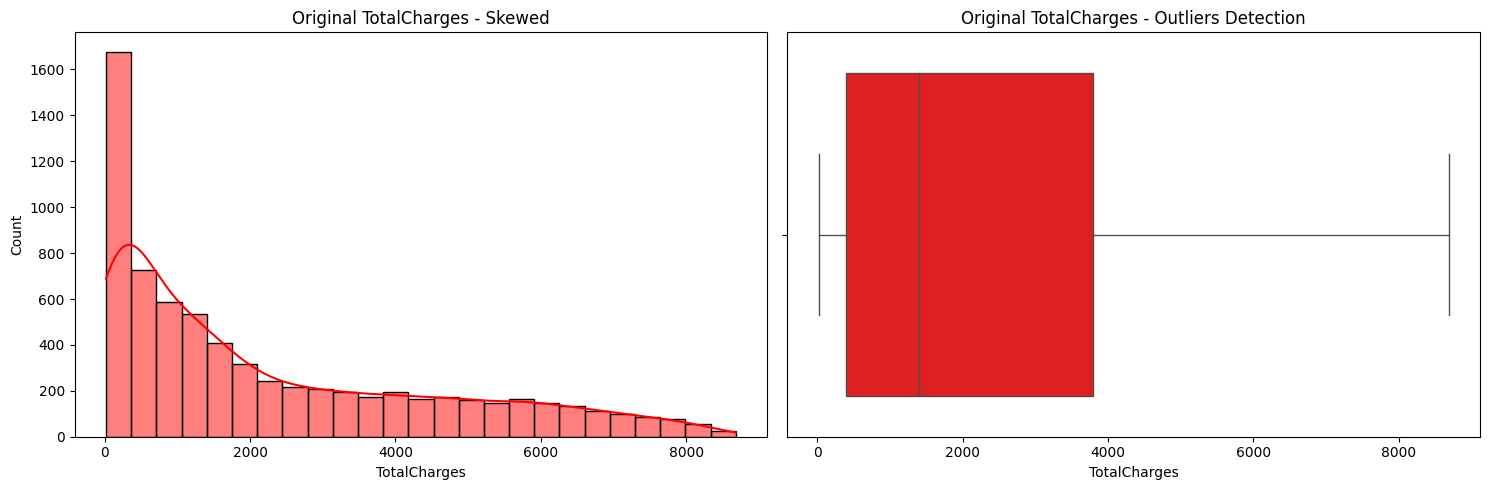

In [ ]:
column_to_check = 'TotalCharges'
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df[column_to_check], kde=True, ax=axes[0], color='red')
axes[0].set_title(f"Original {column_to_check} - Skewed")

sns.boxplot(x=df[column_to_check], ax=axes[1], color='red')
axes[1].set_title(f"Original {column_to_check} - Outliers Detection")


plt.tight_layout()
plt.show()

In [ ]:
df['TotalCharges_Fixed'] = np.sqrt(df['TotalCharges'])

print(f"--- Statistics for {column_to_check} (After Sqrt Transformation) ---")
print(df['TotalCharges_Fixed'].describe())

--- Statistics for TotalCharges (After Sqrt Transformation) ---
count    7032.000000
mean       41.001152
std        24.541630
min         4.335897
25%        20.036217
50%        37.382817
75%        61.601441
max        93.192274
Name: TotalCharges_Fixed, dtype: float64


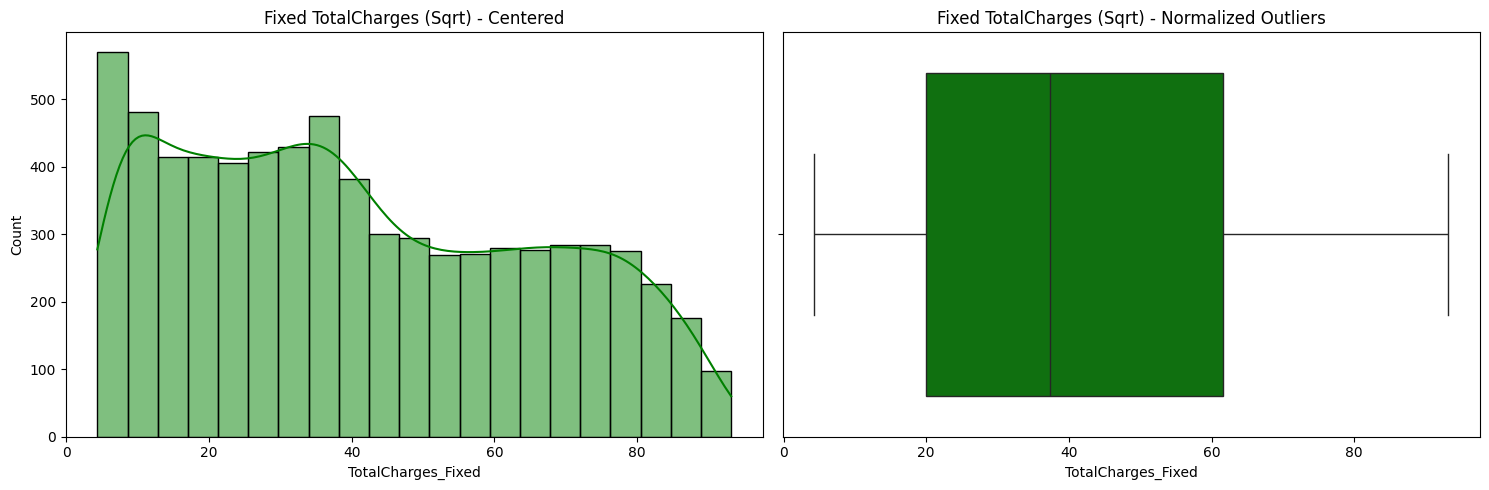

In [ ]:
# Create a new figure and axes for the fixed TotalCharges plots
fig_fixed, axes_fixed = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['TotalCharges_Fixed'], kde=True, ax=axes_fixed[0], color='green')
axes_fixed[0].set_title(f"Fixed {column_to_check} (Sqrt) - Centered")

sns.boxplot(x=df['TotalCharges_Fixed'], ax=axes_fixed[1], color='green')
axes_fixed[1].set_title(f"Fixed {column_to_check} (Sqrt) - Normalized Outliers")

plt.tight_layout()
plt.show()

# Analyzing

EDA plots generated.


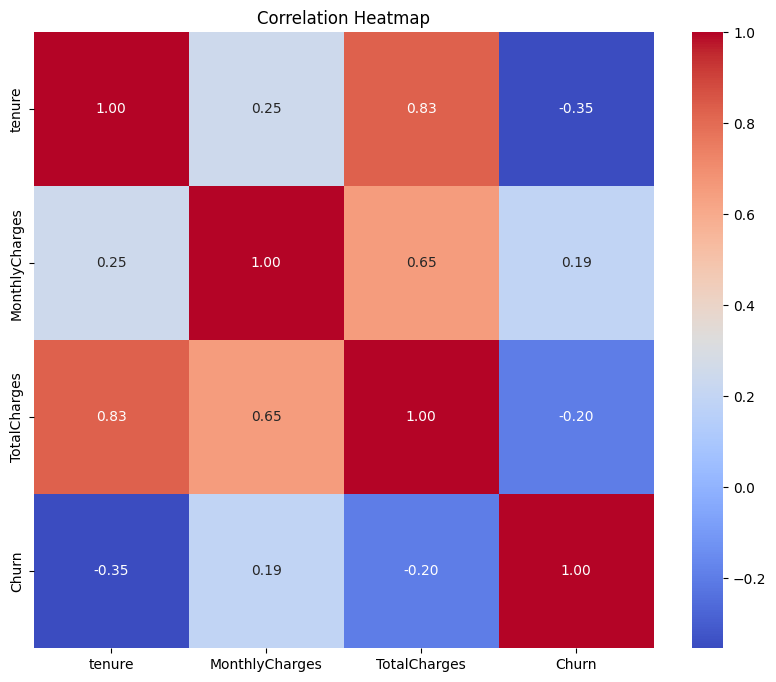

In [ ]:
# Correlation Heatmap for numeric variables
plt.figure(figsize=(10, 8))
sns.heatmap(df_final[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

print("EDA plots generated.")

# VISUALIZATIONS


Text(0.5, 1.0, 'Monthly Charges Distribution')

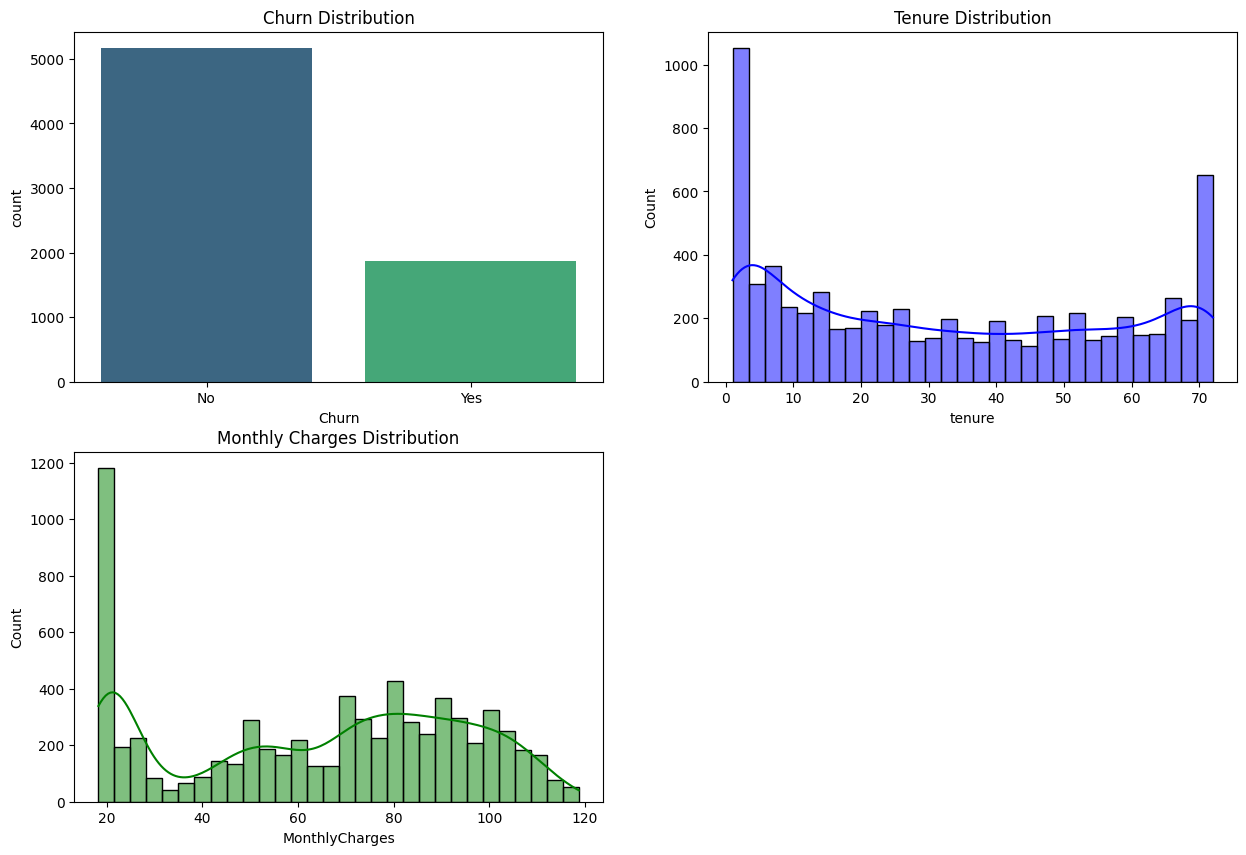

In [ ]:

# CHART 1: Univariate Analysis (Distributions)
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
sns.countplot(x='Churn', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('Churn Distribution')

plt.subplot(2, 2, 2)
sns.histplot(df['tenure'], bins=30, kde=True, color='blue')
plt.title('Tenure Distribution')

plt.subplot(2, 2, 3)
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color='green')
plt.title('Monthly Charges Distribution')

#plt.subplot(2, 2, 4)
#sns.histplot(df['TotalCharges'], bins=30, kde=True, color='red')
#plt.title('Total Charges Distribution (Original)')
#plt.tight_layout()
#plt.show()

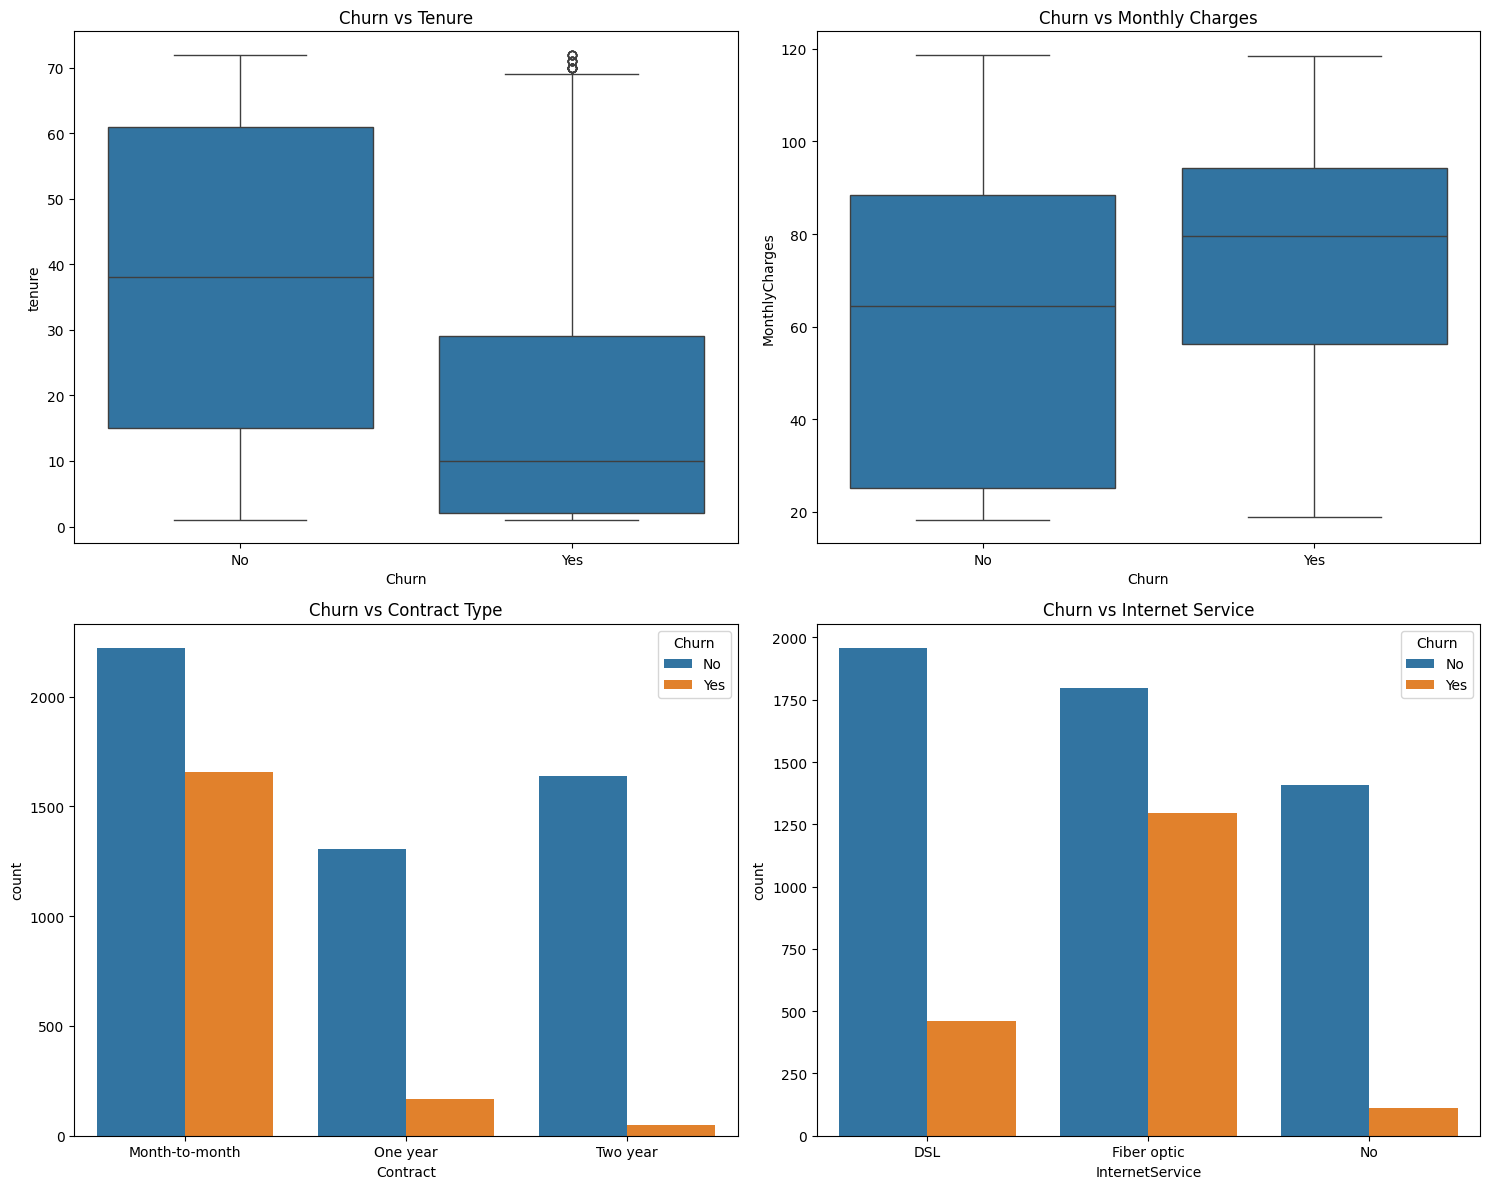

In [ ]:
# CHART 2: Bivariate Analysis (Churn Drivers)
plt.figure(figsize=(15, 12))
plt.subplot(2, 2, 1)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Churn vs Tenure')

plt.subplot(2, 2, 2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Churn vs Monthly Charges')

plt.subplot(2, 2, 3)
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn vs Contract Type')

plt.subplot(2, 2, 4)
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn vs Internet Service')
plt.tight_layout()
plt.show()

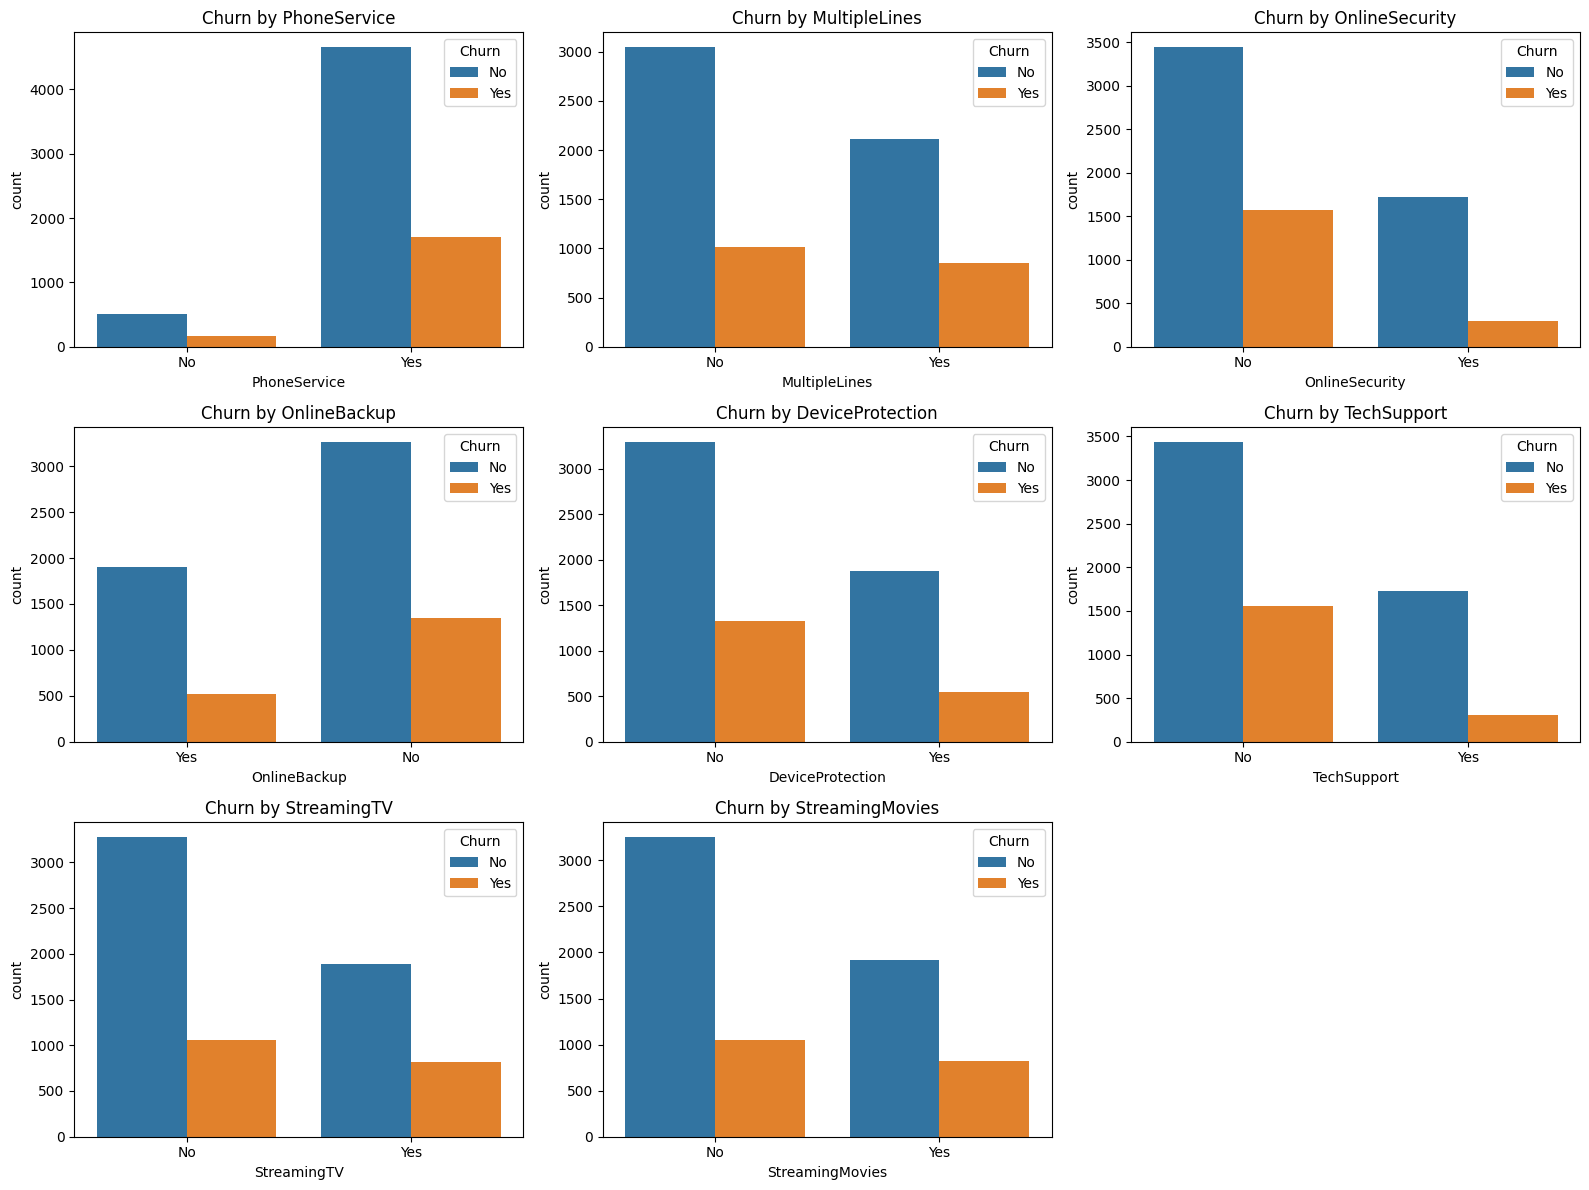

In [ ]:
# CHART 3: Simplified Services Impact
services = ['PhoneService'] + cols_to_simplify
plt.figure(figsize=(16, 12))
for i, service in enumerate(services, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=service, hue='Churn', data=df)
    plt.title(f'Churn by {service}')
plt.tight_layout()
plt.show()

# Analysis of the Relationship: Between Tenure and Total Charge

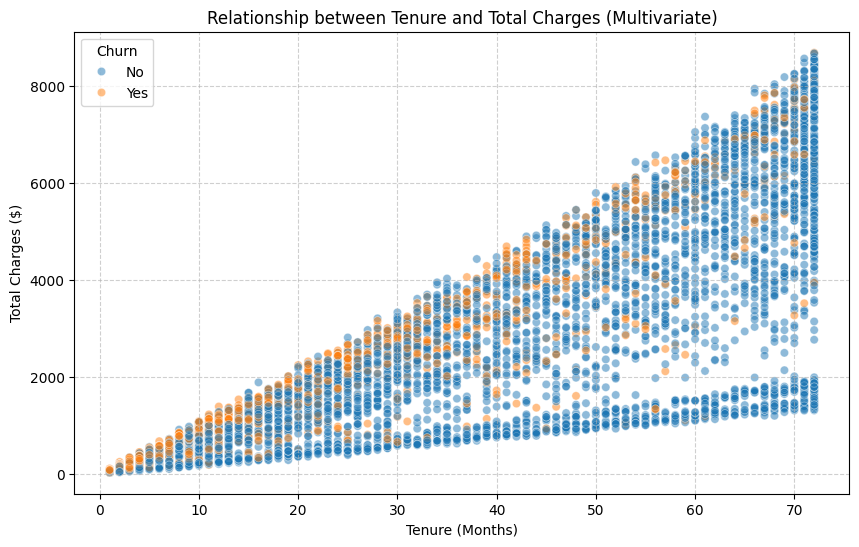

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='tenure', y='TotalCharges', hue='Churn', alpha=0.5)

plt.title('Relationship between Tenure and Total Charges (Multivariate)')
plt.xlabel('Tenure (Months)')
plt.ylabel('Total Charges ($)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()